In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from dataset import SkinDataset

# Parametry
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512

print(f"Używam urządzenia: {DEVICE}")
if DEVICE == "cuda":
    print(f"Model karty: {torch.cuda.get_device_name(0)}")

Używam urządzenia: cuda
Model karty: NVIDIA GeForce RTX 3080


In [6]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.Rotate(limit=35, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

In [7]:
full_dataset = SkinDataset(root_dir="../dataset_final", transform=train_transform)

# Podział 80/20
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# Zmiana transformacji dla walidacji (nie chcemy tam rotacji)
val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [8]:
model = smp.Unet(
    encoder_name="resnet34",        # Lekki i szybki enkoder
    encoder_weights="imagenet",     # Transfer learning
    in_channels=3,
    classes=1,                      # Wyjście binarne
    activation=None
).to(DEVICE)

# Łączymy Dice Loss (dobry dla kształtów) i BCE (klasyczny dla pikseli)
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()

# Definicja funkcji łączonej (Lambda lub prosta funkcja)
def loss_fn(predictions, targets):
    return dice_loss(predictions, targets) + bce_loss(predictions, targets)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler() # Przyspiesza trenowanie na RTX 3080 (Mixed Precision)

C:\Users\Admin\AppData\Local\Temp\ipykernel_13332\1554679758.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # Przyspiesza trenowanie na RTX 3080 (Mixed Precision)


In [11]:
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    
    for batch_idx, (data, targets) in enumerate(train_loader):
        data = data.to(DEVICE)
        targets = targets.float().unsqueeze(1).to(DEVICE)

        # Forward
        with torch.cuda.amp.autocast():
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {total_loss/len(train_loader):.4f}")
    
    # Tutaj warto dodać zapisywanie modelu co kilka epok
    # if (epoch + 1) % 5 == 0:
    #     torch.save(model.state_dict(), f"outputs/models/unet_skin_epoch_{epoch+1}.pth")

C:\Users\Admin\AppData\Local\Temp\ipykernel_13332\558744582.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/50], Loss: 0.1188
Epoch [2/50], Loss: 0.1178
Epoch [3/50], Loss: 0.1042
Epoch [4/50], Loss: 0.0967
Epoch [5/50], Loss: 0.0946
Epoch [6/50], Loss: 0.0936
Epoch [7/50], Loss: 0.0862
Epoch [8/50], Loss: 0.0823
Epoch [9/50], Loss: 0.0785
Epoch [10/50], Loss: 0.0730
Epoch [11/50], Loss: 0.0694
Epoch [12/50], Loss: 0.0673
Epoch [13/50], Loss: 0.0641
Epoch [14/50], Loss: 0.0618
Epoch [15/50], Loss: 0.0599
Epoch [16/50], Loss: 0.0582
Epoch [17/50], Loss: 0.0602
Epoch [18/50], Loss: 0.0871
Epoch [19/50], Loss: 0.0947
Epoch [20/50], Loss: 0.0735
Epoch [21/50], Loss: 0.0597
Epoch [22/50], Loss: 0.0541
Epoch [23/50], Loss: 0.0512
Epoch [24/50], Loss: 0.0492
Epoch [25/50], Loss: 0.0483
Epoch [26/50], Loss: 0.0466
Epoch [27/50], Loss: 0.0457
Epoch [28/50], Loss: 0.0449
Epoch [29/50], Loss: 0.0433
Epoch [30/50], Loss: 0.0429
Epoch [31/50], Loss: 0.0424
Epoch [32/50], Loss: 0.0720
Epoch [33/50], Loss: 0.0634
Epoch [34/50], Loss: 0.0481
Epoch [35/50], Loss: 0.0461
Epoch [36/50], Loss: 0.0418
E

In [13]:
torch.save(model.state_dict(), f"models/unet_skin_1.pth")

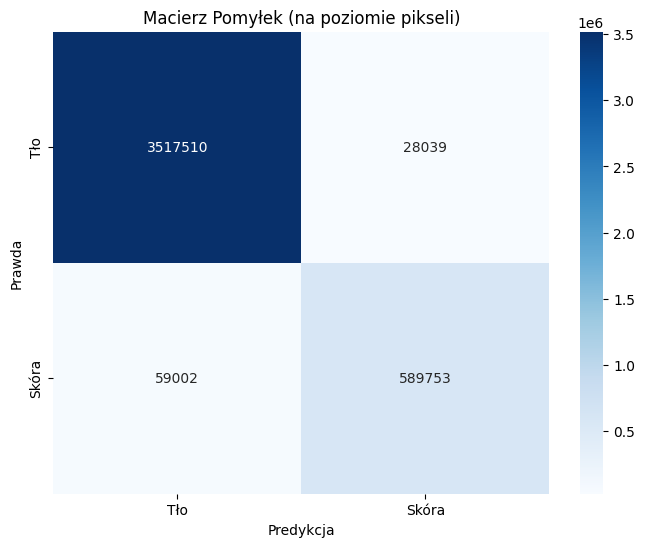

Bieżące IoU dla klasy Skóra: 0.8714


In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device).int()
            
            outputs = model(images)
            preds = (torch.sigmoid(outputs) > 0.5).int()
            
            # Spłaszczamy do 1D, żeby policzyć statystyki dla pikseli
            all_preds.extend(preds.view(-1).cpu().numpy())
            all_targets.extend(masks.view(-1).cpu().numpy())
            
            break # Usuń to, jeśli chcesz policzyć dla CAŁEGO zbioru (może zająć chwilę)

    # Obliczanie macierzy pomyłek
    cm = confusion_matrix(all_targets, all_preds)
    
    # Wyświetlanie
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Tło', 'Skóra'], yticklabels=['Tło', 'Skóra'])
    plt.xlabel('Predykcja')
    plt.ylabel('Prawda')
    plt.title('Macierz Pomyłek (na poziomie pikseli)')
    plt.show()

    # Obliczanie IoU (Jaccard Index)
    # IoU = TP / (TP + FP + FN)
    tn, fp, fn, tp = cm.ravel()
    iou = tp / (tp + fp + fn)
    print(f"Bieżące IoU dla klasy Skóra: {iou:.4f}")

evaluate_model(model, val_loader, DEVICE)